In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/IQ-OTH_NCCD lung cancer dataset.txt
/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (246).jpg
/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (155).jpg
/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (311).jpg
/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (45).jpg
/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (298).jpg
/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (359).jpg
/kaggle/input/datasets/hamdallak/the-iqot

In [3]:
import os

dataset_path = '/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'

folders = ['Normal cases', 'Benign cases', 'Malignant cases']

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")
    else:
        print(f"{folder}: NOT FOUND")

Normal cases: 416 images
Benign cases: NOT FOUND
Malignant cases: 561 images


In [4]:
import os

dataset_path = '/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'

print("All folders found:")
for item in os.listdir(dataset_path):
    print(f"  '{item}'")

All folders found:
  'IQ-OTH_NCCD lung cancer dataset.txt'
  'Normal cases'
  'Bengin cases'
  'Malignant cases'


In [5]:
import os

dataset_path = '/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'

folders = ['Normal cases', 'Bengin cases', 'Malignant cases']

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    count = len(os.listdir(folder_path))
    print(f"{folder}: {count} images")
    

Normal cases: 416 images
Bengin cases: 120 images
Malignant cases: 561 images


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Ready to build!")

2026-03-11 05:11:26.846943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773205887.057235      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773205887.117020      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773205887.599057      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773205887.599114      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773205887.599118      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Ready to build!


In [7]:
dataset_path = '/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'

# Rename bengin to a clean label mapping
import shutil, pathlib

# We'll use ImageDataGenerator which needs a specific folder structure
# Our folders are already structured correctly, we just note the class names
class_names = ['Normal cases', 'Bengin cases', 'Malignant cases']
print("Classes:", class_names)
print("Dataset path exists:", os.path.exists(dataset_path))

Classes: ['Normal cases', 'Bengin cases', 'Malignant cases']
Dataset path exists: True


In [13]:
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1
)

train_data = datagen_train.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data = datagen_train.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Class indices:", train_data.class_indices)

Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.
Class indices: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}


In [14]:
# Handle the imbalance (Benign only has 120 images vs 500+)
labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Load EfficientNetB0 pretrained on ImageNet (millions of images)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base — we don't retrain it, just use what it already knows
base_model.trainable = False

# Add our own classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(3, activation='softmax')(x)  # 3 classes

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built successfully!")
print(f"Total layers: {len(model.layers)}")


Class weights: {0: np.float64(3.048611111111111), 1: np.float64(0.651818856718634), 2: np.float64(0.8788788788788788)}
Model built successfully!
Total layers: 243


In [15]:
# Handle the imbalance (Benign only has 120 images vs 500+)
labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Load EfficientNetB0 pretrained on ImageNet (millions of images)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base — we don't retrain it, just use what it already knows
base_model.trainable = False

# Add our own classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(3, activation='softmax')(x)  # 3 classes

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built successfully!")
print(f"Total layers: {len(model.layers)}")

Class weights: {0: np.float64(3.048611111111111), 1: np.float64(0.651818856718634), 2: np.float64(0.8788788788788788)}
Model built successfully!
Total layers: 243


In [16]:
history = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    class_weight=class_weight_dict,
    verbose=1
)

print("Training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7095 - loss: 0.7672 - val_accuracy: 0.6758 - val_loss: 0.6956
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 511ms/step - accuracy: 0.8223 - loss: 0.4837 - val_accuracy: 0.6941 - val_loss: 0.6875
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 542ms/step - accuracy: 0.8049 - loss: 0.4745 - val_accuracy: 0.6804 - val_loss: 0.7366
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 505ms/step - accuracy: 0.8768 - loss: 0.3968 - val_accuracy: 0.7123 - val_loss: 0.6802
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 513ms/step - accuracy: 0.8741 - loss: 0.3660 - val_accuracy: 0.7215 - val_loss: 0.7062
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 549ms/step - accuracy: 0.8893 - loss: 0.3371 - val_accuracy: 0.6712 - val_loss: 0.8803
Epoch 7/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 536ms/step - accuracy: 0.8555 - loss: 0.3694 - val_accuracy: 0.7534 - val_loss: 0.6905
Epoch 8/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 517ms/step - accuracy: 0.8888 - loss: 0.3105 - val_accurac

Model saved!


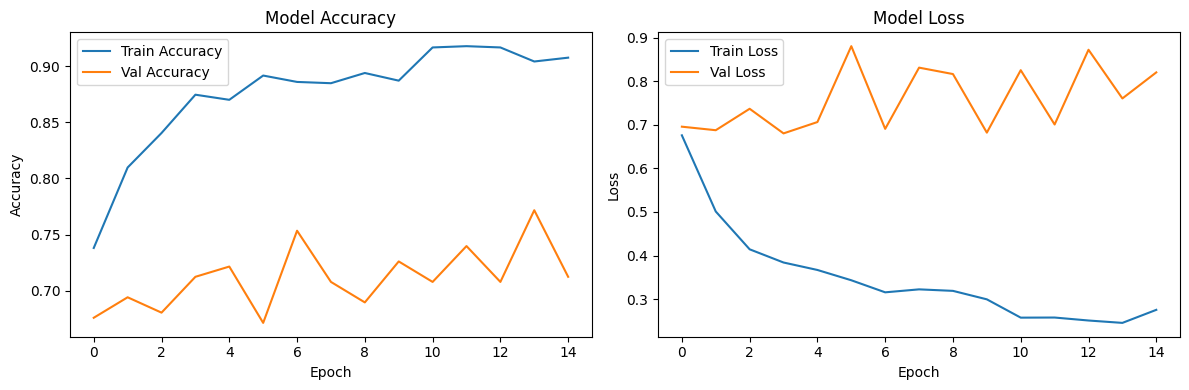

Charts saved!


In [17]:
# Save the model
model.save('/kaggle/working/cancer_detector.keras')
print("Model saved!")

# Plot accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png')
plt.show()
print("Charts saved!")

In [19]:
import numpy as np

# Class mapping
class_labels = {0: 'Benign', 1: 'Malignant', 2: 'Normal'}

def get_recommendation(predicted_class, confidence):
    if predicted_class == 2:  # Normal
        return {
            'status': 'NORMAL',
            'urgency': 'Routine',
            'recommendation': 'No signs of malignancy detected.',
            'next_steps': [
                'Continue annual screening as recommended',
                'Maintain healthy lifestyle',
                'Schedule next routine scan in 12 months'
            ]
        }
    elif predicted_class == 0:  # Benign
        return {
            'status': 'BENIGN FINDING',
            'urgency': 'Low-Medium',
            'recommendation': 'Non-cancerous abnormality detected.',
            'next_steps': [
                'Follow-up CT scan recommended in 3-6 months',
                'Consult with pulmonologist for evaluation',
                'Monitor for any changes in symptoms'
            ]
        }
    elif predicted_class == 1:  # Malignant
        if confidence > 0.85:
            return {
                'status': 'MALIGNANT - HIGH CONFIDENCE',
                'urgency': 'URGENT',
                'recommendation': 'High probability of malignancy detected.',
                'next_steps': [
                    'Immediate oncologist referral required',
                    'PET scan and biopsy recommended within 48 hours',
                    'Do not delay — contact specialist today'
                ]
            }
        else:
            return {
                'status': 'MALIGNANT - REVIEW NEEDED',
                'urgency': 'High',
                'recommendation': 'Possible malignancy detected, radiologist review needed.',
                'next_steps': [
                    'Radiologist review recommended within 24 hours',
                    'Follow-up imaging required',
                    'Schedule oncology consultation this week'
                ]
            }

# Test it works
test_result = get_recommendation(1, 0.91)
print("Test recommendation:")
print(f"Status: {test_result['status']}")
print(f"Urgency: {test_result['urgency']}")
print(f"Recommendation: {test_result['recommendation']}")
print("Next Steps:")
for step in test_result['next_steps']:
    print(f"  - {step}")

Test recommendation:
Status: MALIGNANT - HIGH CONFIDENCE
Urgency: URGENT
Recommendation: High probability of malignancy detected.
Next Steps:
  - Immediate oncologist referral required
  - PET scan and biopsy recommended within 48 hours
  - Do not delay — contact specialist today


In [20]:
!pip install gradio -q
print("Gradio installed!")


Gradio installed!


In [21]:
import gradio as gr
from tensorflow.keras.applications.efficientnet import preprocess_input
from PIL import Image
import numpy as np

def analyze_scan(image):
    # Prep the image
    img = image.resize((224, 224))
    img_array = np.array(img)
    if img_array.shape[-1] == 4:  # remove alpha channel if present
        img_array = img_array[:, :, :3]
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Run prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = float(np.max(predictions[0]))

    # Get recommendation
    result = get_recommendation(predicted_class, confidence)

    # Format output
    class_labels = {0: 'Benign', 1: 'Malignant', 2: 'Normal'}
    output = f"""
🔬 SCAN ANALYSIS RESULT
========================
Diagnosis: {class_labels[predicted_class]}
Confidence: {confidence:.1%}

📋 STATUS: {result['status']}
⚠️ URGENCY: {result['urgency']}

{result['recommendation']}

📌 RECOMMENDED NEXT STEPS:
"""
    for i, step in enumerate(result['next_steps'], 1):
        output += f"\n{i}. {step}"

    output += "\n\n⚠️ DISCLAIMER: This is a research tool only. Not for clinical use."
    return output

demo = gr.Interface(
    fn=analyze_scan,
    inputs=gr.Image(type="pil", label="Upload CT Scan"),
    outputs=gr.Textbox(label="Analysis Result", lines=20),
    title="🫁 AI Lung Cancer Screening Tool",
    description="Upload a chest CT scan image to receive an AI-powered preliminary analysis and recommended next steps.",
    examples=[]
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://bf4a165dec0825aef5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


2026-03-11 05:39:06.365615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 05:39:06.501373: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 05:39:07.183309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 05:39:07.319140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [22]:
import os
print("Files saved in working directory:")
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  {f} — {size/1024/1024:.1f} MB")

Files saved in working directory:
  .virtual_documents — 0.0 MB
  cancer_detector.keras — 18.1 MB
  training_results.png — 0.1 MB
  .gradio — 0.0 MB
